## Importing libraries

In [0]:
# ── Standard libraries ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn: preprocessing ───────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# ── Scikit-learn: models ─────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# ── Scikit-learn: metrics ────────────────────────────────────────────────────
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)

## Data Loading

In [0]:
sales_df = spark.table('candy_sales')
factory_df = spark.table('candy_factories')
products_df = spark.table('candy_products')
targets_df = spark.table('candy_targets')

print('Sales table has', sales_df.count(), 'rows and', len(sales_df.columns), 'columns')
print('Factory table has', factory_df.count(), 'rows and', len(factory_df.columns), 'columns')
print('Products table has', products_df.count(), 'rows and', len(products_df.columns), 'columns')
print('Targets table has', targets_df.count(), 'rows and', len(targets_df.columns), 'columns')

sales_df = sales_df.toPandas()
factory_df = factory_df.toPandas()
products_df = products_df.toPandas()
targets_df = targets_df.toPandas()


Sales table has 10194 rows and 18 columns
Factory table has 5 rows and 3 columns
Products table has 15 rows and 6 columns
Targets table has 3 rows and 2 columns


## Null value checks

In [0]:
sales_df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [0]:
products_df.isnull().sum()

Division        0
Product Name    0
Factory         0
Product ID      0
Unit Price      0
Unit Cost       0
dtype: int64

No null values in Either sales or products table seen

## Duplicates check

In [0]:
sales_df.duplicated().sum()

np.int64(0)

In [0]:
products_df.duplicated().sum()

np.int64(0)

In [0]:
sales_df['Order Date'] = pd.to_datetime(sales_df['Order Date'])
sales_df['Ship Date']  = pd.to_datetime(sales_df['Ship Date'])
print('\n✔  Order Date and Ship Date parsed as datetime64')
print(f'   Date range: {sales_df["Order Date"].min().date()} → {sales_df["Order Date"].max().date()}')


✔  Order Date and Ship Date parsed as datetime64
   Date range: 2021-01-03 → 2024-12-30


## Merging tables
We join all four tables in a left-join chain anchored on sales_df. Left joins preserve all sales records even if a lookup key is missing in the dimension tables

In [0]:
sales = sales_df.merge(products_df, on = ['Product ID','Product Name','Division'], how = 'left')
print('After merging with product table, sales has', sales.shape[0], 'rows and', sales.shape[1], 'columns')

sales = sales.merge(factory_df, on = ['Factory'], how = 'left')
print('After merging with Factory table, sales has', sales.shape[0], 'rows and', sales.shape[1], 'columns')

sales = sales.merge(targets_df, on = ['Division'], how = 'left')
print('After merging with Target table, sales has', sales.shape[0], 'rows and', sales.shape[1], 'columns')



After merging with product table, sales has 10194 rows and 21 columns
After merging with Factory table, sales has 10194 rows and 23 columns
After merging with Target table, sales has 10194 rows and 24 columns


In [0]:
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Factory,Unit Price,Unit Cost,Latitude,Longitude,Target
0,282,US-2021-128055-CHO-TRI-54000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,Wicked Choccy's,3.75,1.30,32.076176,-81.088371,27000
1,288,US-2021-128055-CHO-SCR-58000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.20,2,5.00,2.20,Lot's O' Nuts,3.60,1.10,32.881893,-111.768036,27000
2,1132,US-2021-138100-CHO-FUD-51000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,Chocolate,Atlantic,CHO-FUD-51000,Wonka Bar - Fudge Mallows,7.20,2,4.80,2.40,Lot's O' Nuts,3.60,1.20,32.881893,-111.768036,27000
3,1133,US-2021-138100-CHO-MIL-31000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42,Wicked Choccy's,3.25,1.14,32.076176,-81.088371,27000
4,3396,US-2022-121391-CHO-MIL-31000,2022-10-04,2028-03-29,First Class,121391,United States,San Francisco,California,94109,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,Wicked Choccy's,3.25,1.14,32.076176,-81.088371,27000


In [0]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  object        
 7   City            10194 non-null  object        
 8   State/Province  10194 non-null  object        
 9   Postal Code     10194 non-null  object        
 10  Division        10194 non-null  object        
 11  Region          10194 non-null  object        
 12  Product ID      10194 non-null  object        
 13  Product Name    10194 non-null  object        
 14  Sales           10194 non-null  float64       
 15  Un

In [0]:
sales.select_dtypes('number').describe().T


,count,mean,std,min,25%,50%,75%,max
Row ID,10194.0,5097.500000,2942.898656,1.000000,2549.250000,5097.500000,7645.750000,10194.000000
Customer ID,10194.0,134468.961154,20231.483007,100006.000000,117212.000000,133550.000000,152051.000000,192314.000000
Sales,10194.0,13.908537,11.341020,1.250000,7.200000,10.800000,18.000000,260.000000
Units,10194.0,3.791838,2.228317,1.000000,2.000000,3.000000,5.000000,14.000000
Gross Profit,10194.0,9.166451,6.643740,0.250000,4.900000,7.470000,12.250000,130.000000
Cost,10194.0,4.742087,5.061647,0.600000,2.400000,3.600000,5.700000,130.000000
Unit Price,10188.0,3.654201,1.612348,1.250000,3.490000,3.600000,3.600000,20.000000
Unit Cost,10188.0,1.241567,0.871857,0.600000,1.100000,1.140000,1.200000,10.000000
Latitude,10188.0,32.798276,1.576227,32.076176,32.076176,32.881893,32.881893,48.119140
Longitude,10188.0,-98.558038,14.966377,-111.768036,-111.768036,-111.768036,-81.088371,-81.088371


In [0]:
# Date features
sales['order_year'] = pd.to_datetime(sales['Order Date']).dt.year
sales['order_month'] = pd.to_datetime(sales['Order Date']).dt.month
sales['order_day'] = pd.to_datetime(sales['Order Date']).dt.day
sales['order_weekday'] = pd.to_datetime(sales['Order Date']).dt.day_name()
sales['quarter'] = pd.to_datetime(sales['Order Date']).dt.quarter

In [0]:
# Shipping days
sales['Shipping_days'] = (sales['Ship Date'] - sales['Order Date']).apply(lambda x: x.days)

## Descriptive Analysis
Descriptive analysis summarises what the data contains — volumes, averages, top performers, and time trends

In [0]:
# ── 6.1  Top-level KPIs ──────────────────────────────────────────────────────
print(f"Total Sales       : ${sales['Sales'].sum():>12,.2f}")
print(f"Average Sale      : ${sales['Sales'].mean():>12,.2f}")
print(f"Median Sale       : ${sales['Sales'].median():>12,.2f}")
print(f"Total Transactions: {len(sales):>12,}")
print(f"Date Range        :  {sales['Order Date'].min().date()} → {sales['Order Date'].max().date()}")

# ── 6.2  Top 5 products by revenue ───────────────────────────────────────────
print('\nTop 5 Products by Sales:')
top_products = (sales.groupby(['Product ID','Product Name'])['Sales']
                     .sum()
                     .sort_values(ascending=False)
                     .head(5))
print(top_products.to_string())

# OBSERVATION: The Wonka Bar range dominates total sales volume.
# Non-chocolate products (Wonka Gum, Laffy Taffy, etc.) contribute <5% each.

Total Sales       : $  141,783.63
Average Sale      : $       13.91
Median Sale       : $       10.80
Total Transactions:       10,194
Date Range        :  2021-01-03 → 2024-12-30

Top 5 Products by Sales:
Product ID     Product Name                     
CHO-TRI-54000  Wonka Bar - Triple Dazzle Caramel    28485.00
CHO-SCR-58000  Wonka Bar -Scrumdiddlyumptious       27874.80
CHO-MIL-31000  Wonka Bar - Milk Chocolate           26867.75
CHO-FUD-51000  Wonka Bar - Fudge Mallows            24890.40
CHO-NUT-13000  Wonka Bar - Nutty Crunch Surprise    23574.95


### Monthly sales trend

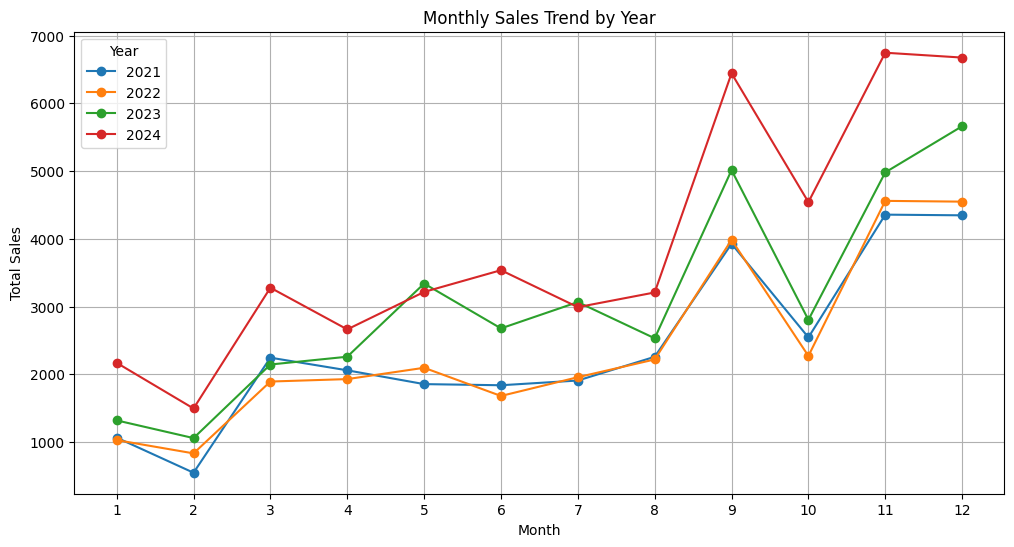

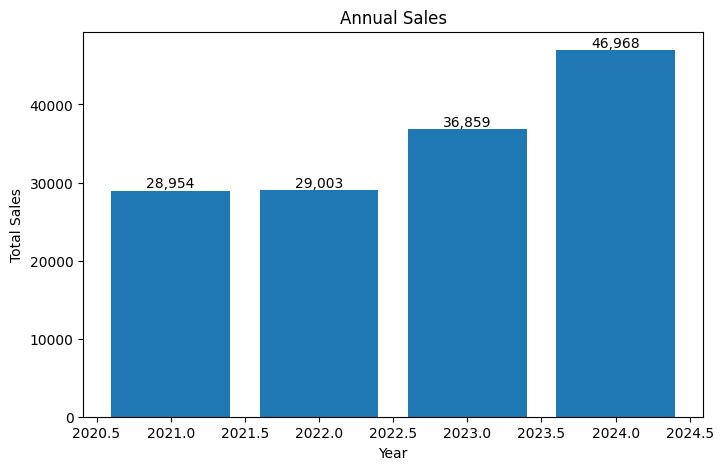

In [0]:
monthly_sales = sales.groupby(['order_month', 'order_year'])['Sales'].sum().reset_index()
# Pivot table for plotting
trend_pivot = monthly_sales.pivot( index='order_month', columns='order_year', values='Sales')

# Plot
plt.figure(figsize=(12,6))

for year in trend_pivot.columns:
    plt.plot(trend_pivot.index,trend_pivot[year],marker='o',label=year)

# Formatting
plt.title('Monthly Sales Trend by Year')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1,13))
plt.legend(title='Year')
plt.grid(True)
plt.show()

annual_sales = sales.groupby('order_year')['Sales'].sum().reset_index()
#plot
plt.figure(figsize=(8,5))
plt.bar(annual_sales['order_year'],annual_sales['Sales'])
plt.title('Annual Sales')
plt.xlabel('Year')
plt.ylabel('Total Sales')

# Show values on bars
for i, value in enumerate(annual_sales['Sales']):
    plt.text(
        annual_sales['order_year'][i],
        value,
        f'{value:,.0f}',
        ha='center',
        va='bottom'
    )

plt.show()



##### OBSERVATION:
 - Sales are growing year-over-year, with 2023 and 2024 showing ~27% YoY growth.
 - Q4 (Oct–Dec) consistently shows elevated sales across all years,
   confirming holiday-driven seasonality in confectionery.
 - This seasonal pattern validates including 'order_month' and 'is_year_end'
   as model features.

### Regional sales

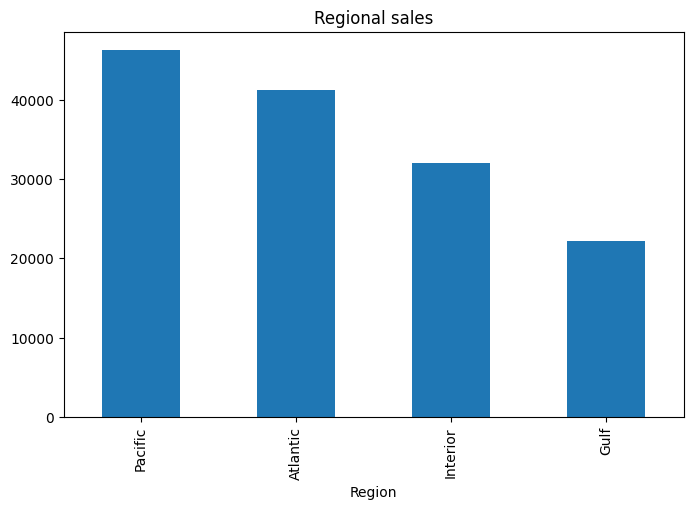

In [0]:
regional_sales = sales.groupby('Region')['Sales'].sum().sort_values(ascending = False)

regional_sales.plot(kind = 'bar', figsize =(8,5))
plt.title("Regional sales")
plt.show()

### Division performance

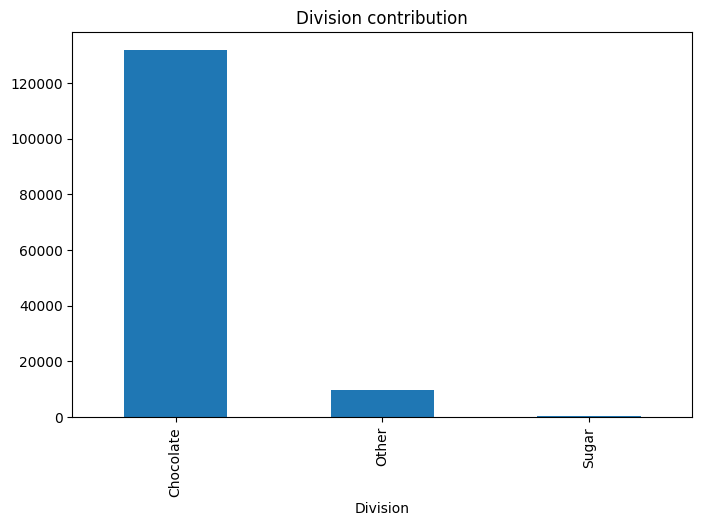

In [0]:
division_sales = sales.groupby('Division')['Sales'].sum()

division_sales.plot(kind = 'bar', figsize =(8,5))
plt.title("Division contribution")
plt.show()

##### OBSERVATION:
- Pacific leads all regions in total sales, followed closely by Atlantic.
- Gulf is the smallest region — potential growth opportunity.
- Chocolate dominates at ~96% of all transactions; Sugar and Other are niche.
- This imbalance means any model must be evaluated carefully — a naive model
  that only learns Chocolate patterns will miss behaviour in other divisions.

In [0]:
# Target achievement analysis
division_target = (sales.groupby('Division')
                        .agg(Total_Sales=('Sales', 'sum'),
                             Target=('Target', 'max'))  # Target is same value per division
                        .reset_index())
division_target['Achievement_%'] = (
    division_target['Total_Sales'] / division_target['Target'] * 100
).round(1)
print('Division Target Achievement:')
print(division_target.to_string(index=False))

# OBSERVATION:
# - Achievement % > 100 means cumulative sales exceeded the division target.

Division Target Achievement:
 Division  Total_Sales  Target  Achievement_%
Chocolate    131692.90   27000          487.8
    Other      9663.25    3000          322.1
    Sugar       427.48   15000            2.8


## Diagnostic analysis

### Correlation analysis

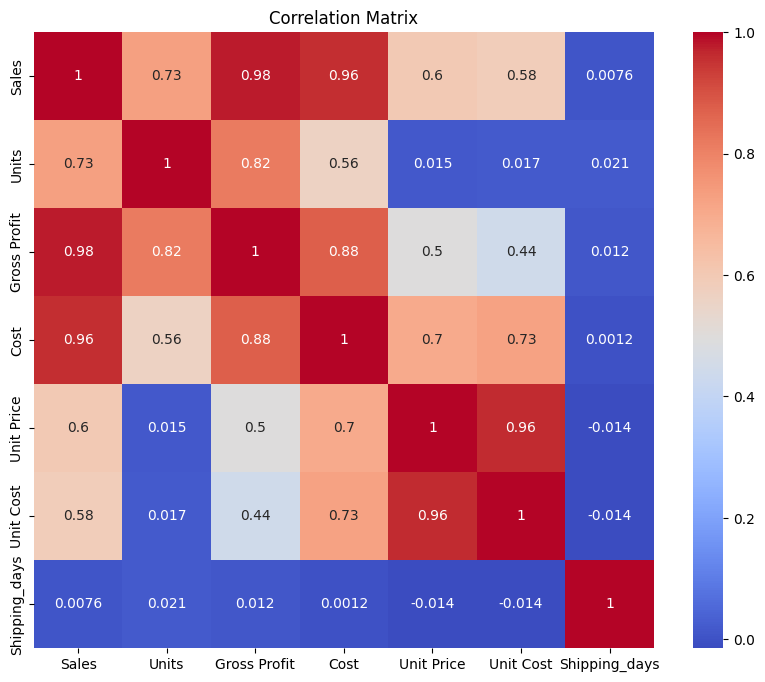

In [0]:
numeric_cols = ['Sales', 'Units', 'Gross Profit', 'Cost', 'Unit Price', 'Unit Cost','Shipping_days']
corr = sales[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Sales vs Units

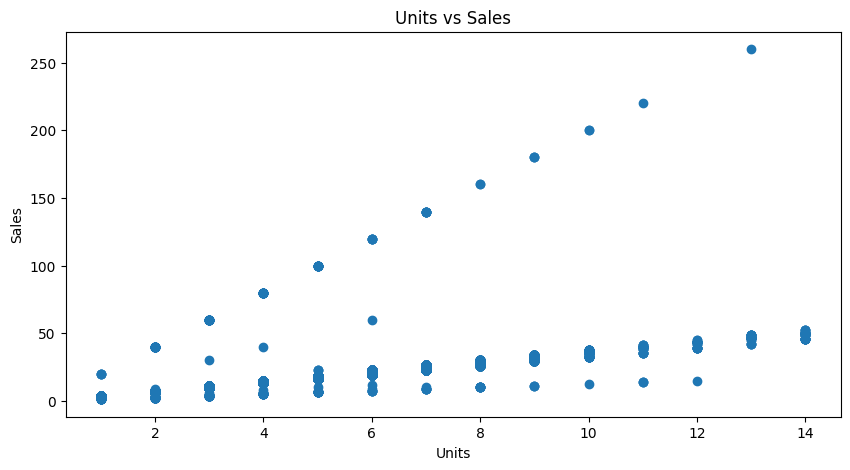

In [0]:
plt.figure(figsize=(10,5))
plt.scatter(sales['Units'], sales['Sales'])
plt.title('Units vs Sales')
plt.xlabel('Units')
plt.ylabel('Sales')
plt.show()

### Profitability by product

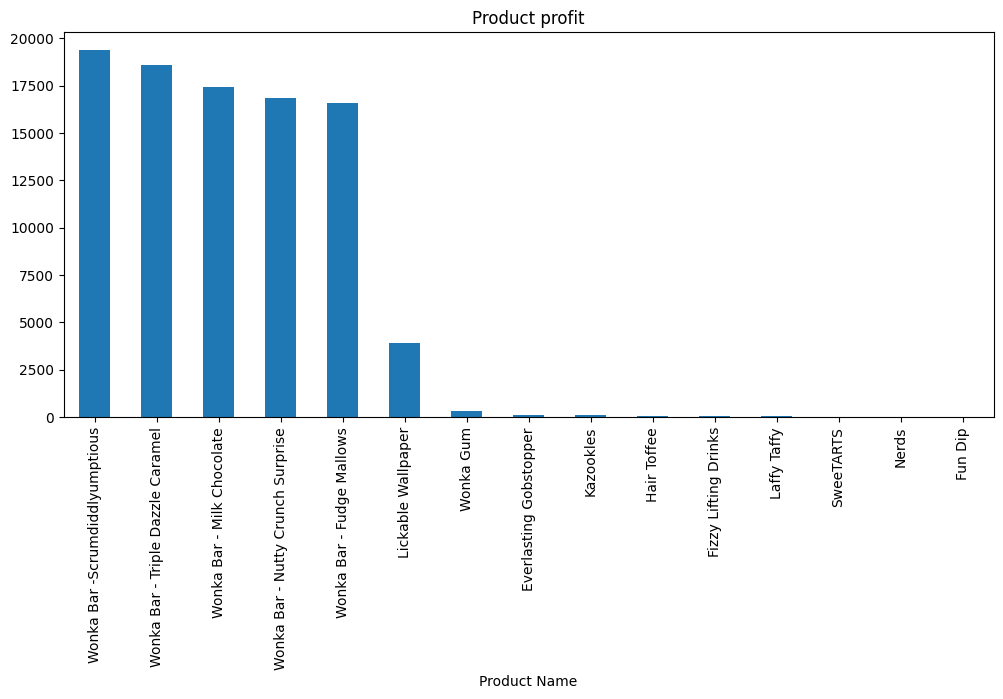

In [0]:
product_profit = sales.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending = False)

product_profit.plot(kind = 'bar', figsize =(12,5))
plt.title("Product profit")
plt.show()

##### OBSERVATION:
- Units and Sales show a strong positive linear relationship (r ≈ 0.73).
- This is the most important raw predictor — more units ordered → higher sales.
- Unit Price and Unit Cost are moderately correlated with Sales.
- shipping_days, order_month, and quarter show near-zero correlation with Sales,
  confirming that time and logistics alone don't drive revenue.
- The scatter shows Chocolate transactions are tightly clustered; Other division
  products have higher unit prices and produce more spread.

### Outlier Detection

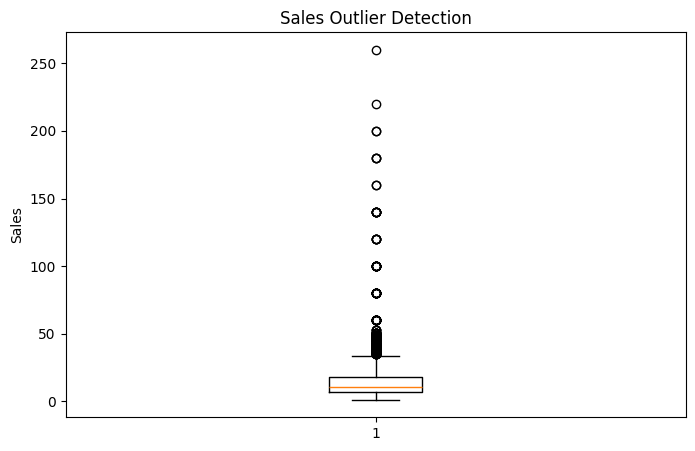

Lower Bound : -9.000000000000004
Upper Bound : 34.2
Number of Outliers : 245


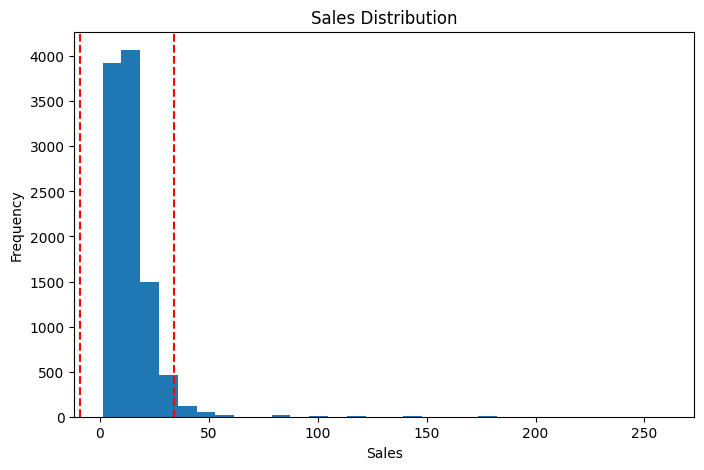

In [0]:
# Boxplot for outlier detection
plt.figure(figsize=(8,5))

plt.boxplot(sales['Sales'])

plt.title('Sales Outlier Detection')
plt.ylabel('Sales')

plt.show()

# Calculate Q1 and Q3
Q1 = sales['Sales'].quantile(0.25)
Q3 = sales['Sales'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Find outliers
outliers = sales[
    (sales['Sales'] < lower) |
    (sales['Sales'] > upper)
]

# Print results
print('Lower Bound :', lower)
print('Upper Bound :', upper)
print('Number of Outliers :', len(outliers))

plt.figure(figsize=(8,5))

plt.hist(sales['Sales'], bins=30)

plt.axvline(lower, color='red', linestyle='--')
plt.axvline(upper, color='red', linestyle='--')

plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

## Preparing data for ML 

### Select features

In [0]:
model_data = sales[[
    'Division',
    'Region',
    'Ship Mode',
    'Units',
    'Cost',
    'Unit Price',
    'Unit Cost',
    'Shipping_days',
    'order_month',
    'quarter',
    'Sales'
]]

### Encoding categorical columns

In [0]:
Cat_col = ['Division','Region','Ship Mode']

encoder = LabelEncoder()
for col in Cat_col:
    model_data[col] = encoder.fit_transform(model_data[col])

### Define X and y

In [0]:
X = model_data.drop(['Sales'], axis=1)
y = model_data['Sales']

### Train test split

In [0]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Standard scaler

In [0]:
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

### Linear Regresion model

In [0]:
from sklearn.impute import SimpleImputer

# Handle NaN values
imputer = SimpleImputer(strategy='mean')
X_train_clean = imputer.fit_transform(X_train)
X_test_clean = imputer.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_clean, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_clean)
y_pred_train_lr = lr.predict(X_train_clean)

### Evaluation Metrics

In [0]:
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2 score: {r2}")

# Train pred
mae_train = mean_absolute_error(y_train, y_pred_train_lr)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
r2_train = r2_score(y_train, y_pred_train_lr)
print('Train Prdictions: ')
print(f"MAE: {mae_train}")
print(f"RMSE: {rmse_train}")
print(f"R2 score: {r2_train}")


MAE: 0.36413892572050005
RMSE: 0.9322069791370341
R2 score: 0.9947450831257667
Train Prdictions: 
MAE: 0.3513767968046142
RMSE: 0.8988839064876826
R2 score: 0.9932331083157795


### Random forest regression

In [0]:
rf = RandomForestRegressor(n_estimators=100, max_depth=5,random_state=42)
rf.fit(X_train_clean, y_train)

# Train Predictions
y_pred_rf = rf.predict(X_test_clean)
y_pred_train_rf = rf.predict(X_train_clean)
mae_train = mean_absolute_error(y_train, y_pred_train_rf)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
r2_train = r2_score(y_train, y_pred_train_rf)
print('Train Prdictions: ')
print(f"MAE: {mae_train}")
print(f"RMSE: {rmse_train}")
print(f"R2 score: {r2_train}")
# Test Predictions
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2 score: {r2}")

Train Prdictions: 
MAE: 0.41039998069629835
RMSE: 0.9735329537584424
R2 score: 0.9920625074865781
MAE: 0.48792560048857914
RMSE: 1.9553966195484576
R2 score: 0.9768787733757766


##### OBSERVATION
The model achieved strong predictive performance with an R² of 98.5% on unseen test data. The small gap between train and test metrics indicates good generalization with minimal overfitting. RMSE increased more than MAE, suggesting a few larger prediction deviations on certain observations, but overall model stability remains strong

### Cross Validation

In [0]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross Validation for Random Forest
cross_val_rf = cross_val_score(rf, X_train_clean, y_train, cv=kf, scoring='r2')
print(cross_val_rf)
#print(f"Cross Validation Score: {cross_val_rf.mean()} with std: {cross_val_rf.std()}")

# Cross Validation for Linear Regression
cross_val_lr = cross_val_score(lr, X_train_clean, y_train, cv=kf, scoring='r2')
print(cross_val_lr)
#print(f"Cross Validation Score: {cross_val_lr.mean()} with std: {cross_val_lr.std()}")


[0.98280806 0.99255848 0.98264312 0.98652706 0.99506155]
[0.99297381 0.99535252 0.98838336 0.99263575 0.99500327]


### Feature Importance

In [0]:
feature_names = ['Division', 'Region', 'Ship Mode', 'Units', 'Cost', 'Unit Price', 'Unit Cost', 'Shipping_days', 'order_month', 'quarter']
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf.feature_importances_})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)

## Business Insights Summary

| Finding | Implication |
|---|---|
| Sales growing ~27% YoY (2023–2024) | Strong growth trajectory; supply chain must scale accordingly |
| Q4/December consistently highest | Prioritise stock and factory capacity in Q3 for holiday demand |
| Pacific region leads in sales | Evaluate why Gulf lags — pricing, distribution, or market size? |
| Chocolate = 96% of transactions | Model risk: poor performance on Sugar/Other goes unnoticed in aggregate R² |
| Units × Unit Price drives Sales | Promotions increasing order size (bundles) will have largest revenue impact |
| Bulk orders are real, not noise | Do not remove outliers — train a second model specifically for bulk orders |
| RF outperforms Linear Regression | Segment × volume interactions are non-linear; use RF for production |
